In [10]:
import numpy as np
import matplotlib.pyplot as plt
from grinsted_firn_model import *

plt.style.use("aslak")

rhoi = 917
g = 9.82
secperyear = 365.25 * 24 * 60 * 60

In [11]:
import pandas as pd
from scipy.interpolate import interp1d

# fscale_estimate = np.std(np.diff(cores[coreidx].raw_rho)/np.sqrt(2))

fname = f"_output/5_fit_spline.parquet"
abtable = pd.read_parquet(fname)

my_afun = lambda rho: interp1d(abtable.rho.values, abtable.a.values,fill_value="extrapolate")(rho)
my_bfun = lambda rho: interp1d(abtable.rho.values, abtable.b.values, fill_value="extrapolate")(rho)



Baseline
z_closeoff: Baseline 62.343065232452226 62.343065232452226 62.343065232452226
deltaAge: Baseline 440.0 440.0 440.0
Accumulation only
z_closeoff: Accumulation only 59.139443911036864 65.22279369555946 62.318875449310404
deltaAge: Accumulation only 382.0 516.0 443.0
Accumulation+strain
z_closeoff: Accumulation+strain 58.258602091546464 59.806264981297254 59.182463440332846
deltaAge: Accumulation+strain 333.0 510.0 420.0
Strain regime change
z_closeoff: Strain regime change 38.5679745985407 62.343065232452226 56.82235541908544
deltaAge: Strain regime change 242.0 440.0 386.0


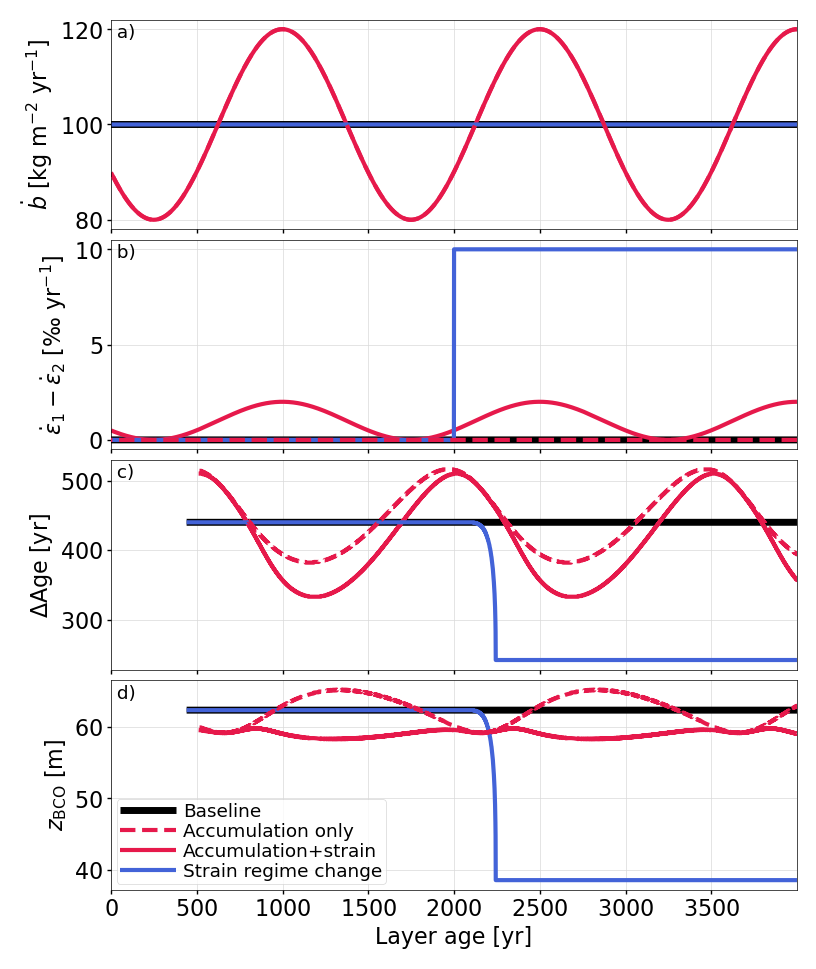

In [12]:
def _expand_to_length(param, target_length):
    """Expand scalar or 1D array to target length."""
    param = np.atleast_1d(param)
    return np.broadcast_to(param, (target_length,)) if param.size == 1 else param


def nonsteadyfirnmodel(tyr=np.linspace(0, 1000), e1=0, e2=0, bdot=0.1, T_celsius=-31, rho_surf=330, A_fun=A_fun, a_fun=a_z07, b_fun=b_z07):
    A = A_fun(T_celsius + 273.15)

    n = len(tyr)
    e1 = _expand_to_length(e1, n)
    e2 = _expand_to_length(e2, n)
    bdot = _expand_to_length(bdot, n)
    rho_surf = _expand_to_length(rho_surf, n)

    # outputs
    dM = np.zeros_like(tyr)  # the layer mass per m2 --- e.g. mass should be "lost" if there is horiz flow divergence.
    rho = np.zeros_like(tyr)
    deltaAge = np.full_like(tyr,np.nan) 
    z_closeoff = np.full_like(tyr,np.nan)
    # todo age of layer!
    dt = (tyr[1] - tyr[0]) * sec_per_year
    ix_of_deepest_open = len(tyr)-1
    for tix in range(len(tyr)):
        ix = len(tyr) - tix - 1  # this is the surface index
        # add a new layer of snow
        dM[ix] = bdot[tix] * dt / sec_per_year  #
        rho[ix] = rho_surf[tix]
        if tix == 0:
            continue
        dt = (tyr[tix] - tyr[tix - 1]) * sec_per_year

        # only work on the indices below the surface but above solid ice
        rhoterm = rhoi - rho[ix + 1 :]
        bottom_index = np.flatnonzero(np.append(rhoterm, 0) == 0)[0]
        rhoterm = rhoterm[:bottom_index]
        curslice = slice(ix + 1, ix + 1 + bottom_index)
        # curslice = slice(ix + 1, -1)

        # update layers below
        sigma_zz = -np.cumsum(dM[ix : ix + bottom_index]) * g  # the mass of the deepest layer does not compress anything.
        # sigma_zz = -np.cumsum(dM[ix:-2]) * g  # the mass of the deepest layer does not compress anything.
        a = a_fun(rho[curslice])
        b = b_fun(rho[curslice])
        # ezz = gagliardini_ezz_vec(sigma_zz, a, b, A, e1[tix], e2[tix])
        ezz = gagliardini_ezz_vec2(sigma_zz, a, b, A, e1[tix], e2[tix])  # faster?

        # what is Drho/Dt:

        DrhoDt = -rho[curslice] * (e1[tix] + e2[tix] + ezz)  # snapshot balance equation
        dM[ix + 1 :] = dM[ix + 1 :] * np.exp(-dt * (e1[tix] + e2[tix]))  # units sec per year...
        # rho[curslice] = rhoi - rhoterm * np.exp(-DrhoDt * dt / rhoterm)  # herron-langway style updating rule
        r0 = rho[curslice]
        rho[curslice] = -(r0 * rhoi) / (np.exp(-(-DrhoDt * rhoi * dt) / (r0 * (r0 - rhoi - 1))) * (r0 - rhoi) - r0)
        #deltaAge[curslice] += (rho[curslice]<830)*dt/sec_per_year
        if rho[ix_of_deepest_open]:
            dH = dM / np.maximum(rho,1)
            z = np.cumsum(dH) - dH / 2
        while rho[ix_of_deepest_open]>830:
            deltaAge[ix_of_deepest_open] = tyr[tix]-tyr[len(tyr)-ix_of_deepest_open]
            z_closeoff[ix_of_deepest_open] = z[ix_of_deepest_open] 
            ix_of_deepest_open = ix_of_deepest_open - 1



        #z = np.cumsum(dH) - dH / 2
        #z_closeoff[curslice] = z[curslice]    
    dH = dM / rho
    z = np.cumsum(dH) - dH / 2
    return z, rho, dM, deltaAge, z_closeoff


# ---- constants ----
div0 = 5e-4 / sec_per_year   # constant divergence (1/s)

# ---- time axis ----
t = np.arange(4000) * 1.0
F = np.cos(2*np.pi*t/1500)  


# ---- cases ----
cases = [
    {
        "name": "Baseline",
        "bdot": lambda: 100 + 0*F,
        "strain": lambda: 0*F,
        "kwargs": dict(color="k", lw=2.5)
    },
    {
        "name": "Accumulation only",
        "bdot": lambda: 100 * (1 + 0.2*F),
        "strain": lambda: 0*F,
        "kwargs": dict(color="C0", lw=1.5, ls='--',zorder=4)
    },
    {
        "name": "Accumulation+strain",
        "bdot": lambda: 100 * (1 + 0.2*F),
        "strain": lambda: 1e-3/sec_per_year * (1 + F)/2,  # 1 permil amplitude
        "kwargs": dict(color="C0", lw=1.5)
    },
    {
        "name": "Strain regime change",
        "bdot": lambda: 100 + 0*F,
        "strain": lambda: (t<t[-1]/2)*0.005/sec_per_year,
        "kwargs": dict(color="C1", lw=1.5)
    }
]

# ---- loop ----
baseline_deltaAge = None

# ---- plotting setup ----
fig, ax = plt.subplots(4, 1, sharex=True, figsize=(3.5, 5))
fig.subplots_adjust(hspace=0.05)

for case in cases:
    print(case["name"])

    bdot = case["bdot"]()
    delta_e = case["strain"]()

    # construct principal strains
    e1 = div0/2 + delta_e
    e2 = div0/2 - delta_e


    # run model
    z, rho, dM, deltaAge, z_closeoff = nonsteadyfirnmodel(
        t, e1, e2, bdot,
        T_celsius=-31,
        rho_surf=330,
        a_fun=my_afun,
        b_fun=my_bfun
    )

    # age axis
    age = np.flip(t[-1] - t)

    # store baseline for anomaly plot
    if case["name"] == "baseline":
        baseline_deltaAge = np.copy(deltaAge)

    kw = case["kwargs"]

    # ---- plotting ----
    plt.sca(ax[0])
    plt.plot(np.flip(t), bdot, **kw)
    plt.ylabel("$\\dot b$ [kg m$^{-2}$ yr$^{-1}$]")

    plt.sca(ax[1])
    plt.plot(np.flip(t), (e1-e2) * sec_per_year * 1000, **kw)
    plt.ylabel(r"$\dot\epsilon_1 - \dot\epsilon_2$ [‰ yr$^{-1}$]")

    plt.sca(ax[2])
    #if baseline_deltaAge is not None:
    #    plt.plot(age, deltaAge - baseline_deltaAge, **kw)
    #    plt.ylabel(r"$\Delta$Age anomaly [yr]")
    #else:
    plt.plot(age, deltaAge, **kw)
    plt.ylabel(r"$\Delta$Age [yr]")

    plt.sca(ax[3])
    plt.plot(age, z_closeoff, label=case["name"], **kw)
    plt.ylabel(r"$z_{\mathrm{BCO}}$ [m]")

    print('z_closeoff:' , case["name"], np.nanmin(z_closeoff), np.nanmax(z_closeoff),np.nanmedian(z_closeoff))
    print('deltaAge:' , case["name"], np.nanmin(deltaAge), np.nanmax(deltaAge),np.nanmedian(deltaAge))

labels = [' a)', ' b)', ' c)', ' d)']

for i, a in enumerate(ax):
    a.margins(y=0.05)
    a.text(
        0.0, 0.98, labels[i],
        transform=a.transAxes,
        fontsize='small',
        va='top'
    )



# ---- final formatting ----
plt.sca(ax[3])
plt.xlabel("Layer age [yr]")
plt.legend(handlelength=3)

import settings
settings.figure_folder = "/home/aslak/Documents/Papers/firnmodel-1d-paper/figures"
plt.savefig(f"{settings.figure_folder}/fig4_implications.png", dpi=300, bbox_inches="tight")

In [13]:
38.5679745985407-62.343065232452226

-23.775090633911525